In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

# image path
workpath = '/content/drive/MyDrive/DigitalImageProcessing/'


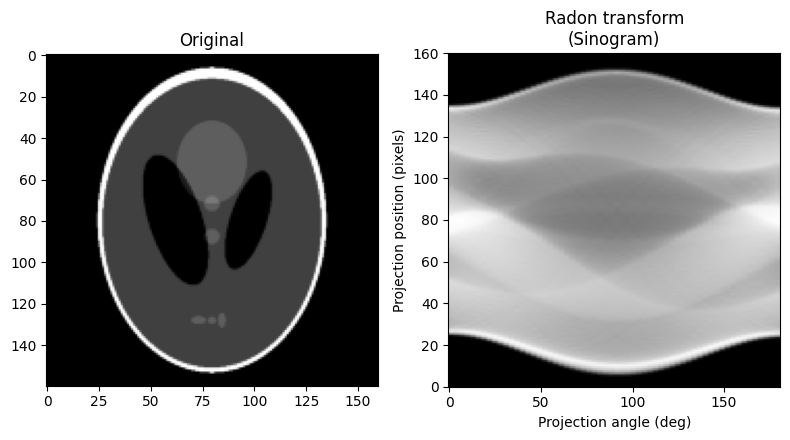

In [ ]:
# Radon transform to create sinograms of an image. Here we use the Phantom Head
image = shepp_logan_phantom()
image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))

ax1.set_title("Original")
ax1.imshow(image, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, 60, endpoint=False)
#theta = np.linspace(0.0, 180.0, max(image.shape), endpoint=False)
sinogram = radon(image, theta=theta)
dx, dy = 0.5 * 180.0 / 60, 0.5 / sinogram.shape[0]
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax2.set_title("Radon transform\n(Sinogram)")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)

fig.tight_layout()
plt.show()

FBP rms reconstruction error: 0.05


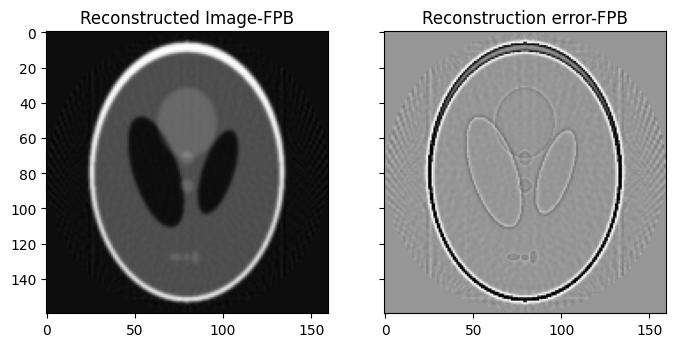

In [ ]:
# Filtered Back-Projection Image reconstruction

from skimage.transform import iradon

reconstruction_fbp = iradon(sinogram, theta=theta, filter_name='hamming')
error = reconstruction_fbp - image
print(f'FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}')

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5), sharex=True, sharey=True)
ax1.set_title("Reconstructed Image-FPB")
ax1.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax2.set_title("Reconstruction error-FPB")
ax2.imshow(reconstruction_fbp - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()

SART (1 iteration) rms reconstruction error: 0.0617
SART (2 iterations) rms reconstruction error: 0.0405
SART (3 iterations) rms reconstruction error: 0.0314


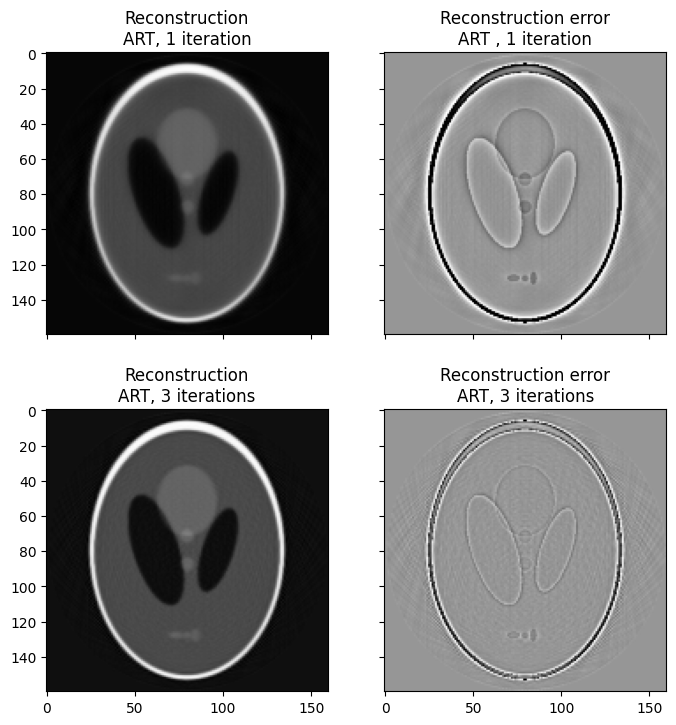

In [ ]:
# ART Image Reconstruction from Sinograms

from skimage.transform import iradon_sart

reconstruction_sart = iradon_sart(sinogram, theta=theta)
error = reconstruction_sart - image
print(
    f'SART (1 iteration) rms reconstruction error: ' f'{np.sqrt(np.mean(error**2)):.3g}'
)

fig, axes = plt.subplots(2, 2, figsize=(8, 8.5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title("Reconstruction\nART, 1 iteration")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nART , 1 iteration")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart)
error = reconstruction_sart2 - image
print(
    f'SART (2 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)


# Run a third iteration of SART by supplying the reconstruction
# from the second iteration as an initial estimate
reconstruction_sart3 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart2)
error = reconstruction_sart3 - image
print(
    f'SART (3 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[2].set_title("Reconstruction\nART, 3 iterations")
ax[2].imshow(reconstruction_sart3, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nART, 3 iterations")
ax[3].imshow(reconstruction_sart3 - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()


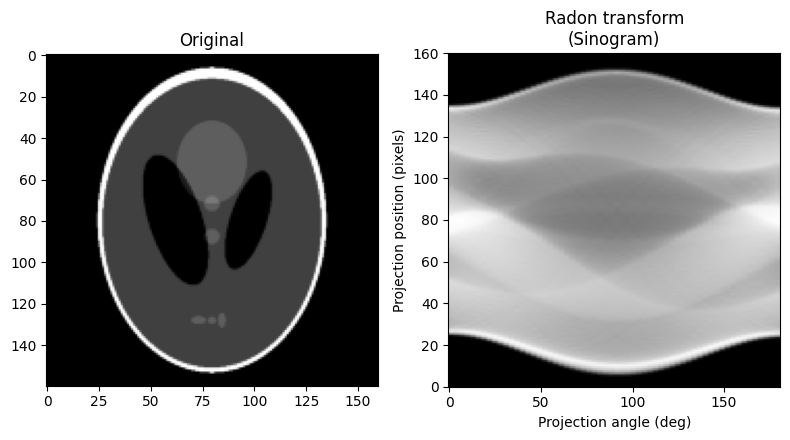

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


MLEM Iteration: 1/200
MLEM Iteration: 2/200
MLEM Iteration: 3/200
MLEM Iteration: 4/200
MLEM Iteration: 5/200
MLEM Iteration: 6/200
MLEM Iteration: 7/200
MLEM Iteration: 8/200
MLEM Iteration: 9/200
MLEM Iteration: 10/200
MLEM Iteration: 11/200
MLEM Iteration: 12/200
MLEM Iteration: 13/200
MLEM Iteration: 14/200
MLEM Iteration: 15/200
MLEM Iteration: 16/200
MLEM Iteration: 17/200
MLEM Iteration: 18/200
MLEM Iteration: 19/200
MLEM Iteration: 20/200
MLEM Iteration: 21/200
MLEM Iteration: 22/200
MLEM Iteration: 23/200
MLEM Iteration: 24/200
MLEM Iteration: 25/200
MLEM Iteration: 26/200
MLEM Iteration: 27/200
MLEM Iteration: 28/200
MLEM Iteration: 29/200
MLEM Iteration: 30/200
MLEM Iteration: 31/200
MLEM Iteration: 32/200
MLEM Iteration: 33/200
MLEM Iteration: 34/200
MLEM Iteration: 35/200
MLEM Iteration: 36/200
MLEM Iteration: 37/200
MLEM Iteration: 38/200
MLEM Iteration: 39/200
MLEM Iteration: 40/200
MLEM Iteration: 41/200
MLEM Iteration: 42/200
MLEM Iteration: 43/200
MLEM Iteration: 44/2

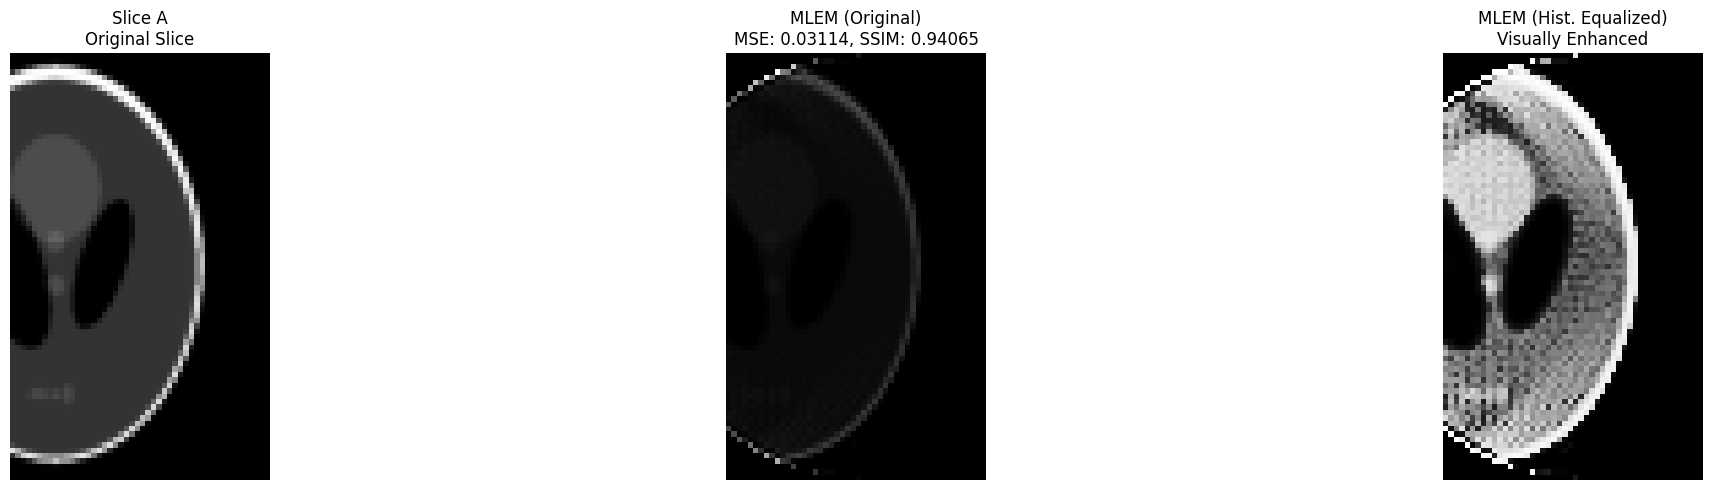

In [ ]:
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import radon, iradon, rescale, iradon_sart
from skimage.metrics import mean_squared_error, structural_similarity as ssim
from skimage.exposure import equalize_hist
import numpy as np
import matplotlib.pyplot as plt

# Radon transform to create sinograms of an image. Here we use the Phantom Head
image = shepp_logan_phantom()
image = rescale(image, scale=0.4, mode='reflect', channel_axis=None)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))

ax1.set_title("Original")
ax1.imshow(image, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, 60, endpoint=False)
#theta = np.linspace(0.0, 180.0, max(image.shape), endpoint=False)
sinogram = radon(image, theta=theta)
dx, dy = 0.5 * 180.0 / 60, 0.5 / sinogram.shape[0]
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sinogram.shape[0]
ax2.set_title("Radon transform\n(Sinogram)")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)

fig.tight_layout()
plt.show()

def center_crop(image, target_shape):
    y, x = image.shape
    target_y, target_x = target_shape
    startx = x // 2 - (target_x // 2)
    starty = y // 2 - (target_y // 2)
    return image[starty:starty+target_y, startx:startx+target_x]

def pad_to_square(image):
    max_side = max(image.shape)
    pad_y = (max_side - image.shape[0]) // 2
    pad_x = (max_side - image.shape[1]) // 2
    return np.pad(image, ((pad_y, max_side - image.shape[0] - pad_y),
                          (pad_x, max_side - image.shape[1] - pad_x)), mode='reflect')

def mlem_reconstruction(sinogram, theta, iterations=100):
    """
    MLEM implementation using Radon and iradon.
    """
    image_size = sinogram.shape[0]
    reconstructed = np.ones((image_size, image_size), dtype=np.float32)

    sensitivity_image = iradon(np.ones_like(sinogram), theta=theta, filter_name=None, circle=True, output_size=image_size)
    sensitivity_image[sensitivity_image == 0] = 1e-6


    for i in range(iterations):
        print(f"MLEM Iteration: {i+1}/{iterations}")
        estimate_proj = radon(reconstructed, theta=theta, circle=True)

        ratio = np.divide(sinogram, estimate_proj + 1e-9)
        correction_factor = iradon(ratio, theta=theta, filter_name=None, circle=True, output_size=image_size)

        reconstructed *= (correction_factor / sensitivity_image)

        reconstructed[reconstructed < 0] = 0

    return reconstructed

def process_slice(image_gray, slice_coords, title):
    slice_img = image_gray[slice_coords[0]:slice_coords[1], slice_coords[2]:slice_coords[3]]
    slice_img = rescale(slice_img, 0.5, mode='reflect', channel_axis=None)
    slice_img_padded = pad_to_square(slice_img)
    theta = np.linspace(0., 180., 180, endpoint=False)
    sinogram = radon(slice_img_padded, theta=theta, circle=True)

    reconstruction_fbp = iradon(sinogram, theta=theta, filter_name='ramp', circle=True)
    reconstruction_fbp_cropped = center_crop(reconstruction_fbp, slice_img.shape)

    reconstruction_mlem = mlem_reconstruction(sinogram, theta, iterations=200)
    reconstruction_mlem_cropped = center_crop(reconstruction_mlem, slice_img.shape)

    mlem_min = reconstruction_mlem_cropped.min()
    mlem_max = reconstruction_mlem_cropped.max()
    if mlem_max > mlem_min:
        reconstruction_mlem_cropped_norm = (reconstruction_mlem_cropped - mlem_min) / (mlem_max - mlem_min)
        reconstruction_mlem_eq = equalize_hist(reconstruction_mlem_cropped_norm)
    else:
        reconstruction_mlem_eq = reconstruction_mlem_cropped.copy()

    mse_fbp = mean_squared_error(slice_img, reconstruction_fbp_cropped)
    ssim_fbp = ssim(slice_img, reconstruction_fbp_cropped, data_range=reconstruction_fbp_cropped.max() - reconstruction_fbp_cropped.min())

    mse_mlem = mean_squared_error(slice_img, reconstruction_mlem_cropped)
    data_range_mlem = reconstruction_mlem_cropped.max() - reconstruction_mlem_cropped.min()
    if data_range_mlem == 0: data_range_mlem = 1

    ssim_mlem = ssim(slice_img, reconstruction_mlem_cropped, data_range=data_range_mlem)


    print(f"{title} - FBP MSE: {mse_fbp:.5f}, SSIM: {ssim_fbp:.5f}")
    print(f"{title} - MLEM (Original) MSE: {mse_mlem:.5f}, SSIM: {ssim_mlem:.5f}")

    # --- Plotting ---
    fig, axes = plt.subplots(1, 3, figsize=(25, 5))
    axes[0].imshow(slice_img, cmap='gray')
    axes[0].set_title(f"{title}\nOriginal Slice")
    axes[0].axis('off')

    axes[1].imshow(reconstruction_mlem_cropped, cmap='gray')
    axes[1].set_title(f"MLEM (Original)\nMSE: {mse_mlem:.5f}, SSIM: {ssim_mlem:.5f}")
    axes[1].axis('off')

    axes[2].imshow(reconstruction_mlem_eq, cmap='gray')
    axes[2].set_title(f"MLEM (Hist. Equalized)\nVisually Enhanced")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Removed the try-except block as it was causing IndentationError and its content was commented out.
# If you intend to load an external image, uncomment and properly indent the code below.
# image = imread(workpath +'Data/example_annotated_images.png')
# if image.shape[-1] == 4:
#     image = image[:, :, :3]
image_gray = image # Using the shepp_logan_phantom image as grayscale

slice_A_coords = [2, 960, 63, 725]
slice_B_coords = [2, 890, 848, 1445]
slice_C_coords = [23, 835, 1555, 2230]

process_slice(image_gray, slice_A_coords, "Slice A")
# process_slice(image_gray, slice_B_coords, "Slice B")
# process_slice(image_gray, slice_C_coords, "Slice C")

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


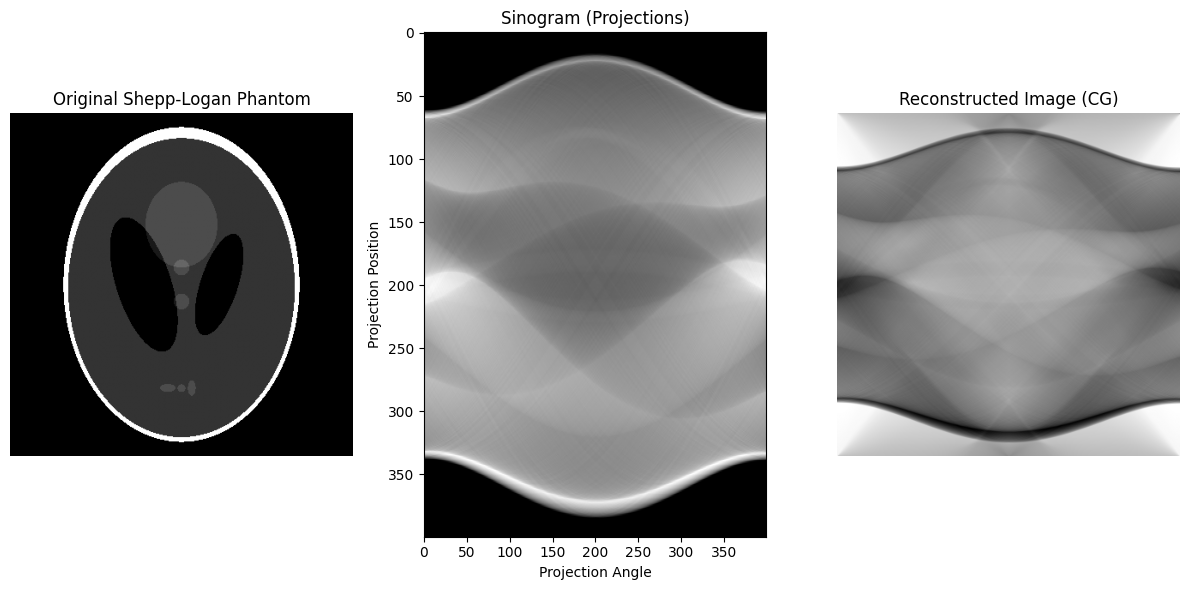

In [ ]:
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon
import matplotlib.pyplot as plt

def conjugate_gradient(A_op, At_op, b, x0, max_iter=100, tol=1e-6):
    """
    Conjugate Gradient method for solving H lambda = z, where A is an operator.
    A_op: Function representing the forward operator A(x).
    At_op: Function representing the adjoint operator A^T(x).
    z: Measured data (sinogram).
    l0: Initial guess for the image.
    max_iter: Maximum number of iterations.
    tol: Tolerance for convergence.
    """
    x = x0.copy()
    r = b - A_op(x)  # Residual
    p = r.copy()    # Search direction
    rsold = np.sum(r * r)

    for i in range(max_iter):
        Ap = A_op(p)
        alpha = rsold / np.sum(p * Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = np.sum(r * r)

        if np.sqrt(rsnew) < tol:
            print(f"Converged in {i+1} iterations.")
            break

        beta = rsnew / rsold
        p = r + beta * p
        rsold = rsnew
    return x

# 1. Generate Shepp-Logan Phantom
phantom_image = shepp_logan_phantom()
image_size = phantom_image.shape[0]

# Define angles for projections
theta = np.linspace(0., 180., max(phantom_image.shape), endpoint=False)

# 2. Forward Projection (Radon Transform)
sinogram_true = radon(phantom_image, theta=theta)

# Define the forward and adjoint operators for CG
def A_operator(x):
    """Forward operator (Radon Transform)."""
    return radon(x, theta=theta)

def At_operator(y):
    """Adjoint operator (Inverse Radon Transform without filtering)."""
    # iradon without filtering is essentially backprojection
    return iradon(y, theta=theta, filter_name=None)

# 3. Initialize reconstruction
x0 = np.zeros_like(phantom_image)

# 4. Perform Conjugate Gradient Reconstruction
reconstructed_image_cg = conjugate_gradient(A_operator, At_operator, sinogram_true, x0, max_iter=50)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(phantom_image, cmap='gray')
plt.title('Original Shepp-Logan Phantom')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sinogram_true, cmap='gray', aspect='auto')
plt.title('Sinogram (Projections)')
plt.xlabel('Projection Angle')
plt.ylabel('Projection Position')

plt.subplot(1, 3, 3)
plt.imshow(reconstructed_image_cg, cmap='gray')
plt.title('Reconstructed Image (CG)')
plt.axis('off')

plt.tight_layout()
plt.show()

CG did not converge after 50 iterations.


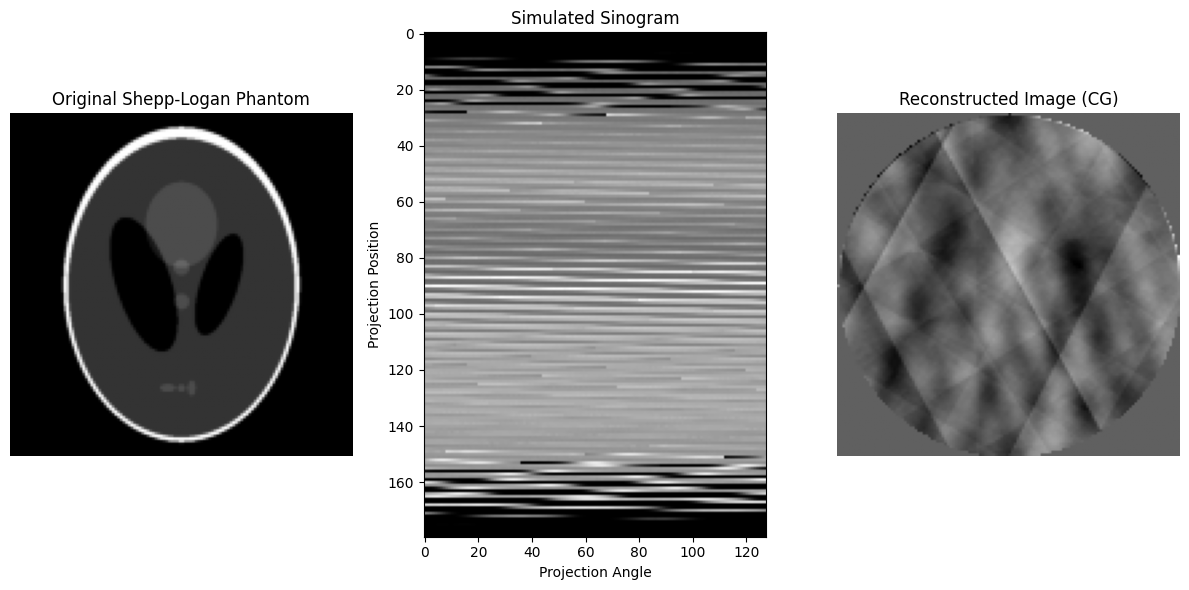

Mean Squared Error (MSE): 0.1116
Structural Similarity Index (SSIM): 0.1041


In [ ]:
import numpy as np
from scipy.sparse.linalg import cg, LinearOperator # Import LinearOperator
from skimage.data import shepp_logan_phantom # Use skimage's phantom for realism
from skimage.transform import radon, iradon, rescale # Use skimage's radon/iradon for accuracy
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity as ssim

# Define the LinearOperator for Radon transform (A)
class RadonLinearOperator(LinearOperator):
    def __init__(self, image_size, angles):
        self.image_size = image_size
        self.angles = angles
        # The shape of the forward operator A: (number of sinogram pixels, number of image pixels)
        # For skimage.radon with circle=True, sinogram_height is image_size
        self.output_size = len(angles) * image_size # Total pixels in the sinogram
        self.input_size = image_size * image_size   # Total pixels in the image
        super().__init__(dtype=np.float64, shape=(self.output_size, self.input_size))

    def _matvec(self, x): # Matrix-vector product (Forward Projection) A @ x
        # Reshape x (1D array) to 2D image
        image = x.reshape((self.image_size, self.image_size))
        # Perform Radon transform
        sinogram = radon(image, theta=self.angles, circle=True)
        # Reshape sinogram to 1D array
        return sinogram.flatten()

    def _rmatvec(self, y): # Reverse matrix-vector product (Backprojection) A.T @ y
        # Reshape y (1D array) to 2D sinogram as it was originally produced by radon: (num_angles, projection_size)
        original_sinogram_2d = y.reshape((len(self.angles), self.image_size))

        # WORKAROUND for skimage.transform.iradon bug in older versions (e.g., 0.19.3)
        # The error "theta does not match the number of projections in radon_image"
        # incorrectly checks radon_image.shape[1] against len(theta),
        # whereas it should check radon_image.shape[0].
        # To bypass this faulty check, we transpose the sinogram.
        # This makes radon_image.shape[1] == len(theta), satisfying the buggy validation.
        sinogram_for_iradon = original_sinogram_2d.T

        # Perform backprojection (adjoint of radon is iradon with filter_name=None)
        reconstructed_image = iradon(sinogram_for_iradon, theta=self.angles, filter_name=None, circle=True, output_size=self.image_size)
        # Reshape reconstructed_image to 1D array
        return reconstructed_image.flatten()

# Define the LinearOperator for A^T A (for solving normal equations)
class AtA_LinearOperator(LinearOperator):
    def __init__(self, A_op):
        self.A_op = A_op
        # The shape of A^T A is (input_size, input_size), which is square
        super().__init__(dtype=np.float64, shape=(A_op.input_size, A_op.input_size))

    def _matvec(self, x): # Matrix-vector product (A.T @ A @ x)
        return self.A_op.rmatvec(self.A_op.matvec(x))

# Main Reconstruction Process
if __name__ == "__main__":
    image_size = 128
    num_angles = 180
    angles = np.linspace(0, 180, num_angles, endpoint=False)

    # Generate true phantom using skimage
    # shepp_logan_phantom() does not take image_size as argument directly.
    # It returns a fixed size image, which we then rescale.
    phantom_base = shepp_logan_phantom()
    true_phantom = rescale(phantom_base, scale=image_size / phantom_base.shape[0], mode='reflect', anti_aliasing=True)
    # Normalize the phantom for consistent metrics
    true_phantom = (true_phantom - np.min(true_phantom)) / (np.max(true_phantom) - np.min(true_phantom))

    # Create the linear operator for Radon transform (A)
    A_operator = RadonLinearOperator(image_size, angles)

    # Simulate projections (measured_sinogram = A @ true_phantom)
    measured_sinogram_flat = A_operator.matvec(true_phantom.flatten())

    # Create the linear operator for A^T A
    A_transpose_A_operator = AtA_LinearOperator(A_operator)

    # Calculate the right-hand side b_prime = A^T b
    rhs = A_operator.rmatvec(measured_sinogram_flat)

    # Initial guess for the image (e.g., all zeros)
    x0 = np.zeros(image_size * image_size)

    # Solve using Conjugate Gradient for A^T A x = A^T b
    reconstructed_image_flat, info = cg(A_transpose_A_operator, rhs, x0=x0, maxiter=50)

    if info > 0:
        print(f"CG did not converge after {info} iterations.")
    elif info < 0:
        print("CG failed with an error.")
    else:
        print("CG converged successfully.")

    reconstructed_image = reconstructed_image_flat.reshape((image_size, image_size))

    # Display results
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(true_phantom, cmap='gray')
    plt.title('Original Shepp-Logan Phantom')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Reshape measured_sinogram_flat back to 2D for display
    sinogram_display = measured_sinogram_flat.reshape(len(angles), image_size)
    plt.imshow(sinogram_display, cmap='gray', aspect='auto')
    plt.title('Simulated Sinogram')
    plt.xlabel('Projection Angle')
    plt.ylabel('Projection Position')

    plt.subplot(1, 3, 3)
    plt.imshow(reconstructed_image, cmap='gray')
    plt.title('Reconstructed Image (CG)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and print metrics
    # Normalize reconstructed image for consistent SSIM calculation
    reconstructed_image_norm = (reconstructed_image - np.min(reconstructed_image)) / (np.max(reconstructed_image) - np.min(reconstructed_image))

    mse = mean_squared_error(true_phantom, reconstructed_image_norm)
    ssim_val = ssim(true_phantom, reconstructed_image_norm, data_range=1.0) # data_range for 0-1 normalized images

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Structural Similarity Index (SSIM): {ssim_val:.4f}")